In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import sqlalchemy as sa
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm

from conf import conf
from g_led import datasets, downsamplers, utils

In [3]:
with hydra.initialize(version_base=utils.HYDRA_INIT['version_base'], config_path='../conf'):
    cfg = hydra.compose(utils.HYDRA_INIT['config_name'], overrides=[
        '+experiment=TrainImagenBackwardFacingStep2DOverfit',

        # 'dataset=BackwardFacingStep2D',
        # 'dataset.time_step_window_size_train=null',
        # 'dataset.time_step_window_size_val=null',
        'dataset/downsampler=DownsamplerGaussian',
        'dataset/upsampler=UpsamplerLinear',
        
        # 'dataset=Macro',
        # 'dataset.split=VAL',
        # 'dataset.batch_size_train=1',
        # 'dataset.batch_size_val=1',
        # 'dataset.initial_sequence_time_step_start=0',
        # 'dataset.initial_sequence_time_step_count=1',
        # # 'dataset.use_sliding_initial_sequence=true',
        # 'dataset.forecast_time_step_count=150',

        # 'dataset.time_step_window_size_train=null',
        # 'dataset.time_step_window_size_val=null',
        
        # 'dataset@dataset.dataset=BackwardFacingStep2D',
        # 'dataset.dataset.batch_size_train=16',
        # 'dataset.dataset.batch_size_val=16',
        # 'dataset/downsampler@dataset.dataset.downsampler=DownsamplerGaussian',
    ])
    engine = conf.get_engine()
    conf.orm.create_all(engine)
    with conf.sa.orm.Session(engine) as db:
        cfg = conf.orm.instantiate_and_insert_config(db, OmegaConf.to_container(cfg, resolve=True))
        # db.commit()
        pprint.pp(cfg.dataset)

BackwardFacingStep2D(_data_dir='/home/ttransue/out/g_led/data',
                     rng_seed=2376999025,
                     _processed_filename='1ffxaq5j',
                     trajectory_count_train=1,
                     trajectory_count_val=1,
                     trajectory_count_test=1,
                     trajectories_are_shared_across_splits=True,
                     trajectory_time_step_size_micro=0.0002,
                     trajectory_time_step_count_micro=2498750,
                     trajectory_time_step_count_drop_first_micro=0,
                     trajectory_time_step_subsample_interval_macro=250,
                     macro_time_step_count_train=10,
                     macro_time_step_count_val=10,
                     macro_time_step_count_test=10,
                     time_step_window_size_train=10,
                     time_step_window_size_val=10,
                     time_step_window_size_test=10,
                     time_step_window_stride_train=1,
        

In [4]:
lightning.pytorch.seed_everything(cfg.rng_seed)
with lightning.pytorch.utilities.seed.isolate_rng():
    dataset = datasets.get_dataset(cfg.dataset)
    dataset.prepare_data()
    dataset.setup('predict')

Seed set to 2376999025


In [5]:
dataset.train.shape

torch.Size([1, 10, 2, 512, 512])

(2, 32, 32)


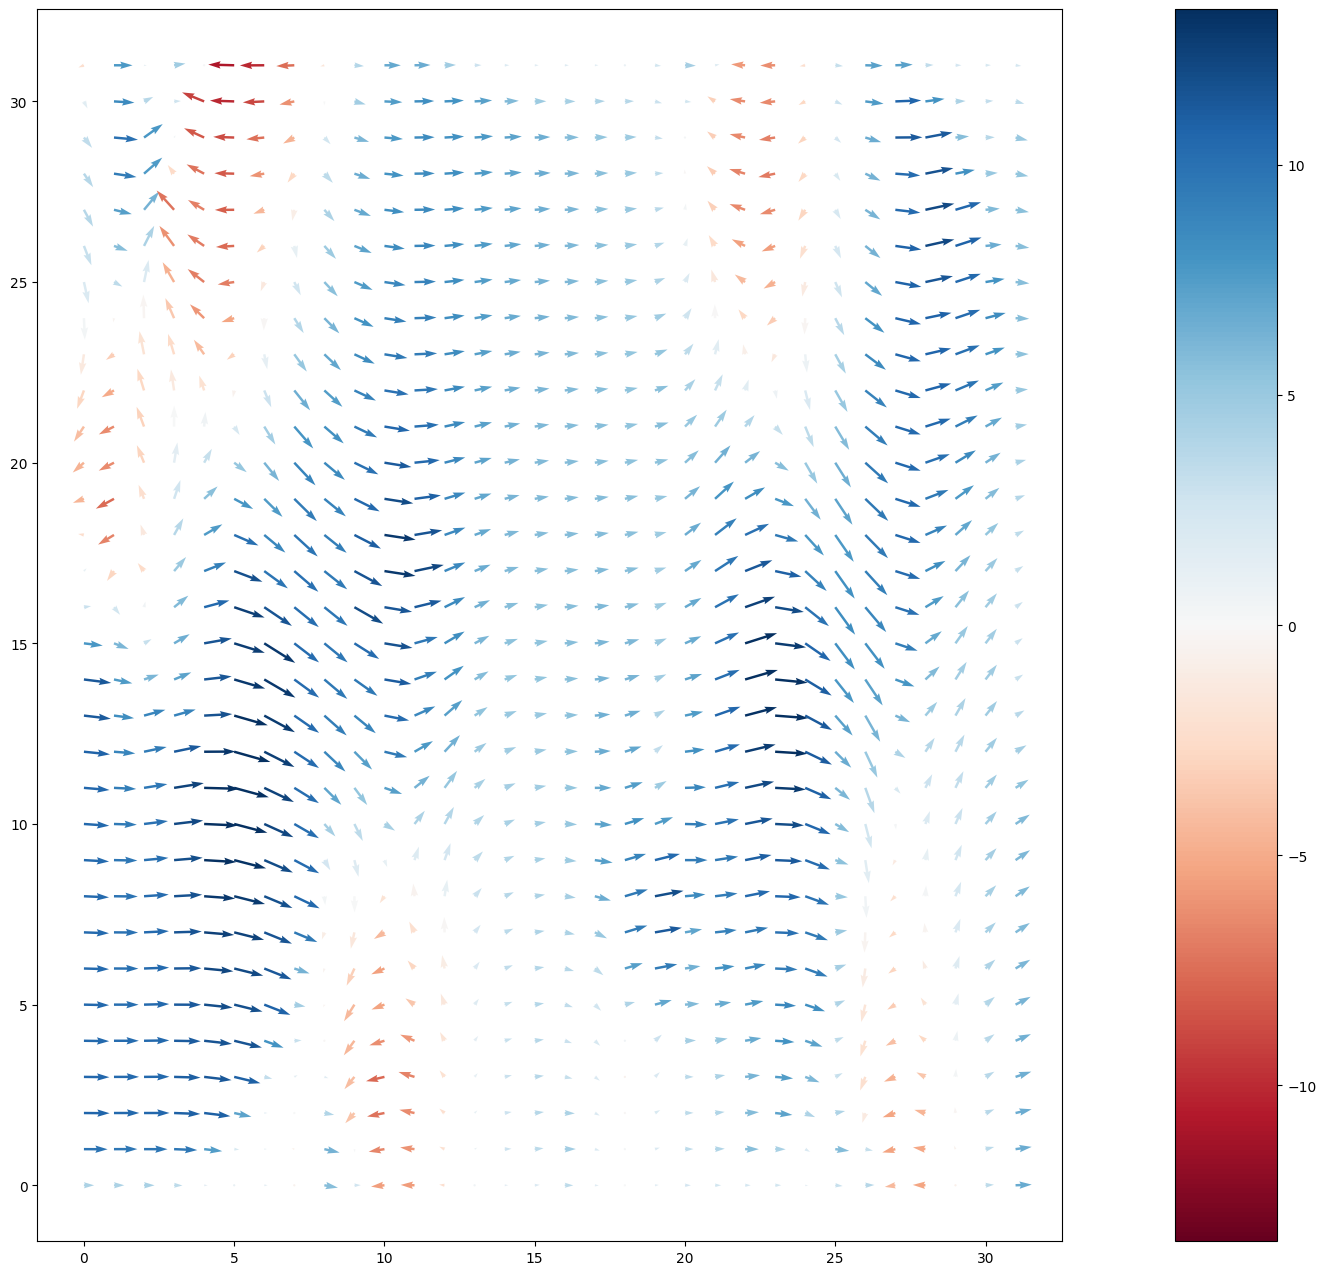

In [12]:
# data = dataset.train[-1, 0, :, 100:300, 100:300].numpy()
downsampler = downsamplers.DownsamplerLinear(cfg.dataset)
# downsampler = downsamplers.DownsamplerGaussian(cfg.dataset)
data = downsampler(dataset.train[-1:, -1:]).numpy()[0, 0]
print(data.shape)
# data = dataset.train[-1, 0].numpy()
fig, axs = plt.subplots(figsize=(16, 16), ncols=2, width_ratios=[10, 1])
color = data[0]
p = .01
v_abs_max = max(np.quantile(color, p), np.quantile(color, 1 - p))
quiver = axs[0].quiver(data[0], data[1], color, cmap='RdBu', norm=matplotlib.colors.Normalize(vmin=-v_abs_max, vmax=v_abs_max))
fig.colorbar(quiver, cax=axs[-1])

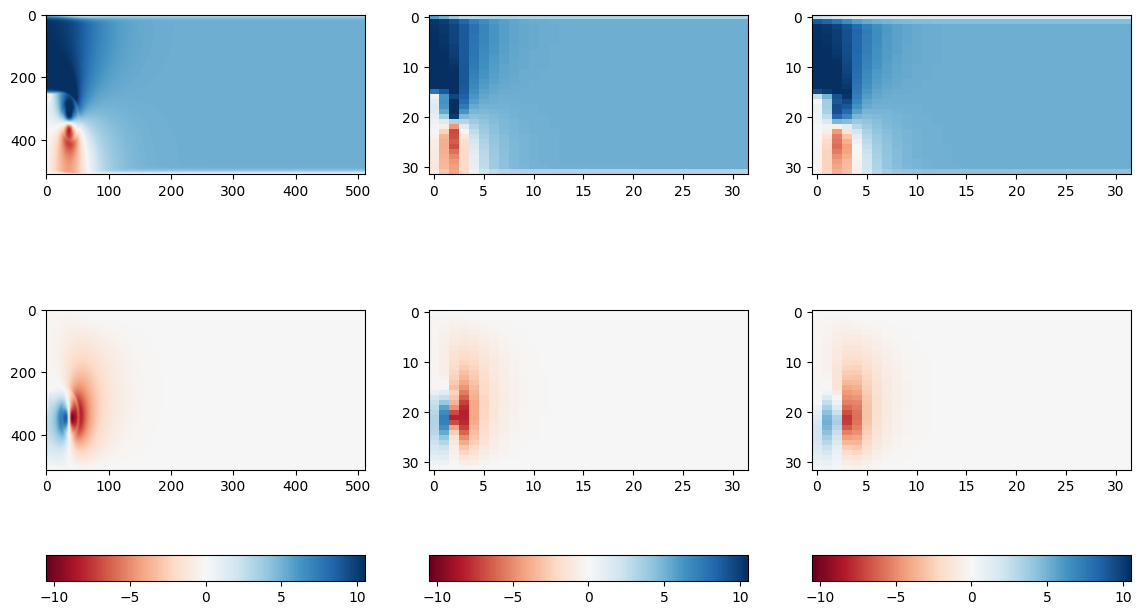

In [7]:
downsampler_list = [lambda x: x, downsamplers.DownsamplerLinear(cfg.dataset), downsamplers.DownsamplerGaussian(cfg.dataset)]
p = .01
data = dataset.train[-1:, [1]]
v_abs_max = max(np.quantile(data, p), np.quantile(data, 1 - p))
fig, axs = plt.subplots(figsize=(14, 8), nrows=data.shape[2] + 1, ncols=len(downsampler_list), height_ratios=[10, 10, 1])
for col, downsampler in enumerate(downsampler_list):
    data_macro = downsampler(data)[0, 0]
    for ax, data_macro_component in zip(axs[:, col], data_macro):
        im_out = ax.imshow(data_macro_component, cmap='RdBu', vmin=-v_abs_max, vmax=v_abs_max, aspect=0.5)
    fig.colorbar(im_out, cax=axs[-1][col], orientation='horizontal')

torch.Size([2, 1, 33, 33])


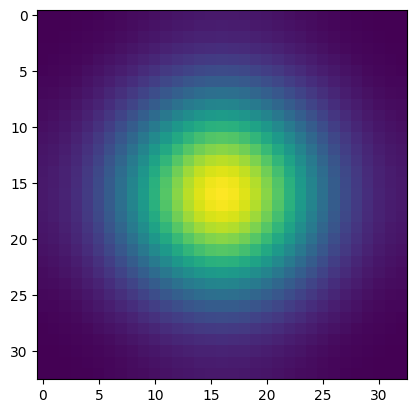

In [4]:
downsampler = downsamplers.DownsamplerGaussian(cfg.dataset)
print(downsampler.downsampler.weight.shape)
plt.imshow(downsampler.downsampler.weight[1, 0])
# plt.imshow(downsampler.init_gaussian_kernel((33, 33), 16*.4)[0, 0], cmap='RdBu', vmin=0)

In [22]:
import matplotlib.animation

RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

Error in callback <function _draw_all_if_interactive at 0x7f49736edb40> (for post_execute), with arguments args (),kwargs {}:


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f4a4bb6cca0>>
Traceback (most recent call last):
  File "/home/ttransue/.cache/uv/archive-v0/FZpmNC0hAgQ-4cOFzLf3c/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 

KeyboardInterrupt



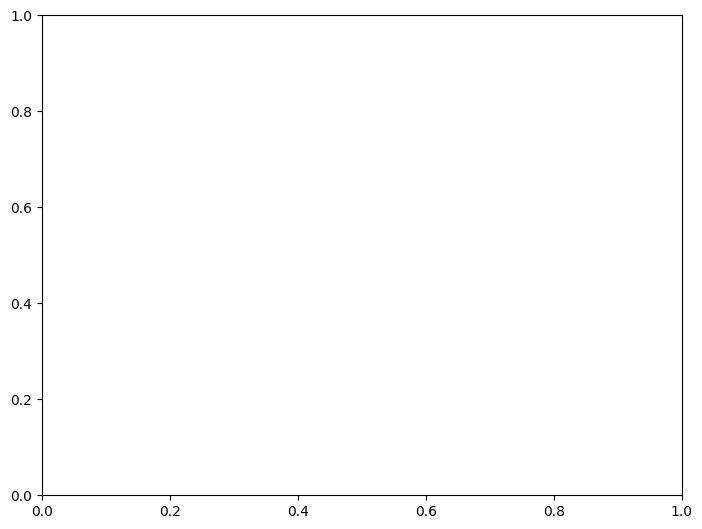

In [58]:
fig, ax = plt.subplots()
fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=None, hspace=None)
frame_artists = []
# downsampler = lambda x: x
# downsampler = models.DownsamplerGaussian(cfg.dataset)
downsampler = models.Downsampler(cfg.dataset)
frame_count = 1000
frames = models.Upsampler(cfg.dataset)(downsampler(dataset.train[:, :frame_count]))[0, :, 0]
for data in frames:
    v_abs_max = max(np.quantile(data, p), np.quantile(data, 1 - p))
    im = ax.imshow(data, cmap='RdBu', vmin=-v_abs_max, vmax=v_abs_max, aspect=0.5, animated=True)
    frame_artists.append([im])
ani = matplotlib.animation.ArtistAnimation(
    fig, frame_artists, interval=50, blit=True,
    # repeat_delay=1000,
)
ani.save(
    'BackwardFacingStep2DFirst1000TimeSteps.mp4',
    savefig_kwargs=dict(
        pad_inches=.06,
    )
)